# Q5: Enhancing K-Means with Lift-Sum Feature Weighting

This rewritten Q5 focuses on one evidence-driven question: can association-rule lift sums identify useful feature weights for K-Means? The logic is:

1. Equal-weight K-Means fails because every standardized feature contributes equally to Euclidean distance.
2. Q2 RBF-SVM permutation importance shows that feature importance is highly uneven.
3. Class-stratified FP-Growth rules provide a lift-sum feature-importance signal.
4. Applying lift-derived weights improves PCA geometry and K-Means ARI.
5. Randomly assigning the same weights to different features tests whether the feature-to-weight mapping matters.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr, spearmanr
from mlxtend.frequent_patterns import fpgrowth, association_rules

Path('report/figures').mkdir(parents=True, exist_ok=True)
Path('results').mkdir(parents=True, exist_ok=True)

df = pd.read_csv('data/mobile_price.csv')
X = df.drop('price_range', axis=1).values
y = df['price_range'].values
feature_names = df.drop('price_range', axis=1).columns.tolist()
class_labels = ['Low cost (0)', 'Medium cost (1)', 'High cost (2)', 'Very high cost (3)']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

seeds = [0, 10, 42, 100, 999]
random_permutations = 20
representative_seed = 42

print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes')
print('Features:', feature_names)


Dataset: 2000 samples, 20 features, 4 classes
Features: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']


## Method Diagram


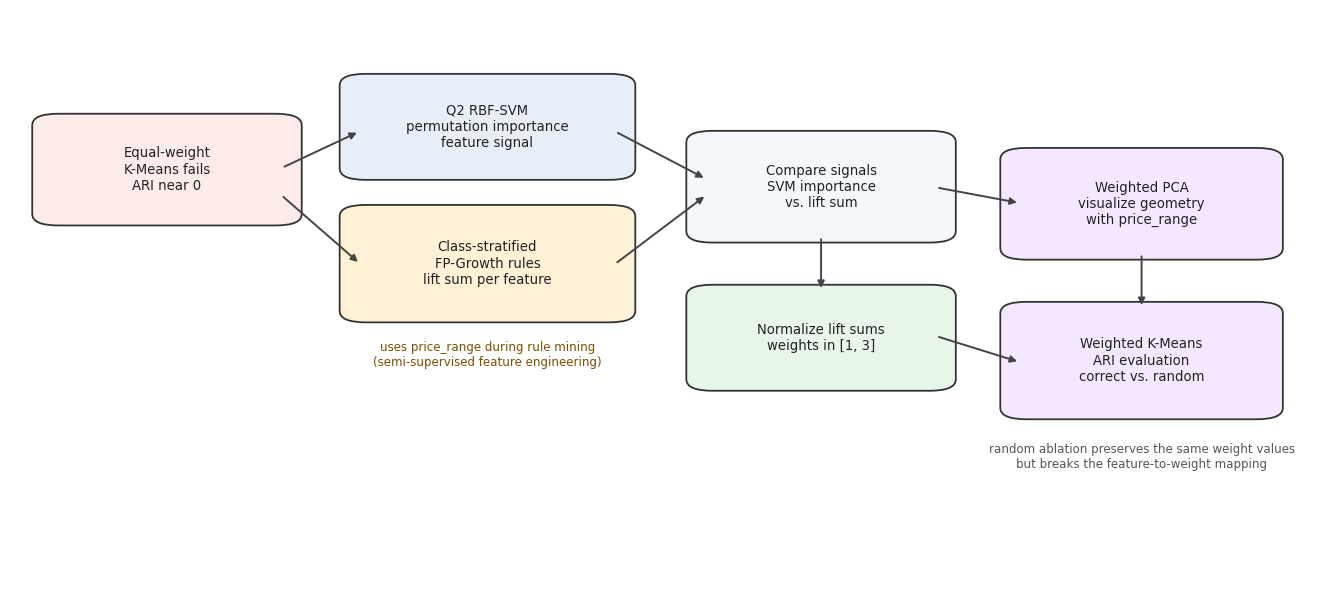

In [2]:
def draw_box(ax, xy, w, h, text, fc, ec='#333333', fontsize=9.5):
    box = patches.FancyBboxPatch(
        xy, w, h,
        boxstyle='round,pad=0.018,rounding_size=0.02',
        linewidth=1.3,
        edgecolor=ec,
        facecolor=fc,
    )
    ax.add_patch(box)
    ax.text(xy[0] + w / 2, xy[1] + h / 2, text, ha='center', va='center', fontsize=fontsize, color='#222222')


def draw_arrow(ax, start, end, color='#444444'):
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='-|>', lw=1.4, color=color, shrinkA=5, shrinkB=5))

fig, ax = plt.subplots(figsize=(13.5, 6.0))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

colors = {
    'problem': '#fdebea',
    'supervised': '#e8eef7',
    'rules': '#fff1d6',
    'weights': '#e8f5e9',
    'model': '#f3e8ff',
    'eval': '#f4f7fb',
}

boxes = {
    'baseline': ((0.035, 0.64), 0.17, 0.16, 'Equal-weight\nK-Means fails\nARI near 0', colors['problem']),
    'svm': ((0.27, 0.72), 0.19, 0.15, 'Q2 RBF-SVM\npermutation importance\nfeature signal', colors['supervised']),
    'rules': ((0.27, 0.47), 0.19, 0.17, 'Class-stratified\nFP-Growth rules\nlift sum per feature', colors['rules']),
    'compare': ((0.535, 0.61), 0.17, 0.16, 'Compare signals\nSVM importance\nvs. lift sum', colors['eval']),
    'weights': ((0.535, 0.35), 0.17, 0.15, 'Normalize lift sums\nweights in [1, 3]', colors['weights']),
    'pca': ((0.775, 0.58), 0.18, 0.16, 'Weighted PCA\nvisualize geometry\nwith price_range', colors['model']),
    'kmeans': ((0.775, 0.30), 0.18, 0.17, 'Weighted K-Means\nARI evaluation\ncorrect vs. random', colors['model']),
}

for xy, w, h, text, fc in boxes.values():
    draw_box(ax, xy, w, h, text, fc)

for start, end in [
    ((0.205, 0.72), (0.27, 0.79)),
    ((0.205, 0.68), (0.27, 0.55)),
    ((0.46, 0.79), (0.535, 0.70)),
    ((0.46, 0.55), (0.535, 0.68)),
    ((0.62, 0.61), (0.62, 0.50)),
    ((0.705, 0.43), (0.775, 0.38)),
    ((0.705, 0.69), (0.775, 0.66)),
    ((0.865, 0.58), (0.865, 0.47)),
]:
    draw_arrow(ax, start, end)

ax.text(0.365, 0.42, 'uses price_range during rule mining\n(semi-supervised feature engineering)', ha='center', va='top', fontsize=8.5, color='#7a4f00')
ax.text(0.865, 0.24, 'random ablation preserves the same weight values\nbut breaks the feature-to-weight mapping', ha='center', va='top', fontsize=8.5, color='#555555')

plt.tight_layout()
plt.savefig('report/figures/q5_method_flowchart.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation Utilities


In [3]:
def hungarian_mapping(y_true, cluster_labels, n_classes=4):
    contingency = pd.crosstab(
        pd.Series(cluster_labels, name='cluster'),
        pd.Series(y_true, name='label'),
    ).reindex(index=range(n_classes), columns=range(n_classes), fill_value=0)
    row_ind, col_ind = linear_sum_assignment(-contingency.values)
    mapping = {row: col for row, col in zip(row_ind, col_ind)}
    mapped = np.array([mapping.get(label, 0) for label in cluster_labels])
    return mapped, contingency


def evaluate_clustering(y_true, cluster_labels, n_classes=4):
    mapped, contingency = hungarian_mapping(y_true, cluster_labels, n_classes=n_classes)
    return {
        'accuracy': accuracy_score(y_true, mapped),
        'precision': precision_score(y_true, mapped, average='macro', zero_division=0),
        'recall': recall_score(y_true, mapped, average='macro', zero_division=0),
        'f1': f1_score(y_true, mapped, average='macro', zero_division=0),
        'ARI': adjusted_rand_score(y_true, cluster_labels),
        'NMI': normalized_mutual_info_score(y_true, cluster_labels),
        'contingency': contingency,
    }


def run_kmeans_evaluation(X_input, method_name, seeds=seeds):
    rows = []
    for seed in seeds:
        km = KMeans(n_clusters=4, random_state=seed, n_init=10)
        clusters = km.fit_predict(X_input)
        metrics = evaluate_clustering(y, clusters)
        metrics.pop('contingency')
        metrics['seed'] = seed
        metrics['method'] = method_name
        rows.append(metrics)
    return pd.DataFrame(rows)


## Baseline: Equal-Weight K-Means


In [4]:
baseline_results = run_kmeans_evaluation(X_scaled, 'Baseline equal-weight K-Means')
print('Baseline equal-weight K-Means:')
print(baseline_results[['seed', 'accuracy', 'f1', 'ARI', 'NMI']].to_string(index=False))
print('\nBaseline means:')
print(baseline_results[['accuracy', 'f1', 'ARI', 'NMI']].mean().to_string())


Baseline equal-weight K-Means:
 seed  accuracy       f1      ARI      NMI
    0    0.2945 0.292637 0.005263 0.007146
   10    0.2955 0.293648 0.005610 0.007544
   42    0.2970 0.295035 0.005962 0.007902
  100    0.2955 0.293510 0.005520 0.007423
  999    0.2985 0.295579 0.006834 0.009012

Baseline means:
accuracy    0.296200
f1          0.294082
ARI         0.005838
NMI         0.007806


## Q2 RBF-SVM Permutation Importance


Top SVM permutation importances:
      feature  svm_importance_mean  svm_importance_std
          ram             0.688000            0.024370
battery_power             0.215500            0.015658
     px_width             0.123333            0.015496
    px_height             0.109917            0.014296
    mobile_wt             0.013083            0.005191
   int_memory             0.000833            0.001972
           pc             0.000500            0.001000
         blue             0.000000            0.000000
     dual_sim             0.000000            0.000000
  clock_speed             0.000000            0.000000


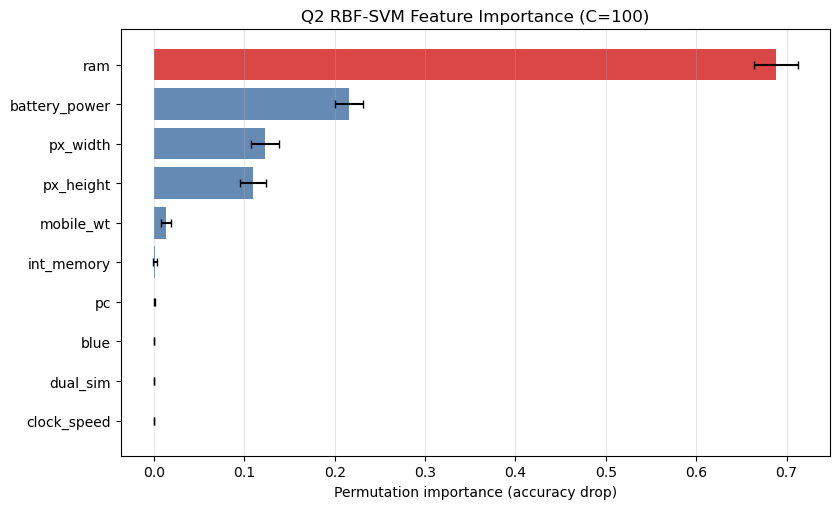

In [5]:
X_temp_svm, X_test_svm, y_temp_svm, y_test_svm = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train_svm, X_val_svm, y_train_svm, y_val_svm = train_test_split(
    X_temp_svm, y_temp_svm, test_size=0.25, random_state=42
)

svm_ref = SVC(C=100, kernel='rbf', gamma='scale', random_state=42)
svm_ref.fit(X_train_svm, y_train_svm)

perm = permutation_importance(
    svm_ref,
    X_test_svm,
    y_test_svm,
    scoring='accuracy',
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
)

svm_importance = pd.DataFrame({
    'feature': feature_names,
    'svm_importance_mean': perm.importances_mean,
    'svm_importance_std': perm.importances_std,
}).sort_values('svm_importance_mean', ascending=False).reset_index(drop=True)
svm_importance.to_csv('results/q5_svm_permutation_importance.csv', index=False)

print('Top SVM permutation importances:')
print(svm_importance.head(10).to_string(index=False))

plot_df = svm_importance.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.5, 5.2))
colors_svm = ['#d62728' if f == 'ram' else '#4c78a8' for f in plot_df['feature']]
ax.barh(
    plot_df['feature'],
    plot_df['svm_importance_mean'],
    xerr=plot_df['svm_importance_std'],
    color=colors_svm,
    alpha=0.86,
    capsize=3,
)
ax.set_xlabel('Permutation importance (accuracy drop)')
ax.set_title('Q2 RBF-SVM Feature Importance (C=100)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('report/figures/q5_svm_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## Lift-Sum Feature Importance From Association Rules


In [6]:
def discretize_343(series, name):
    min_val = series.min()
    max_val = series.max()
    range_val = max_val - min_val
    if range_val == 0:
        return pd.Series(f'{name}_medium', index=series.index)
    low_upper = min_val + 0.3 * range_val
    med_upper = min_val + 0.7 * range_val
    result = pd.Series(index=series.index, dtype=str)
    result[series <= low_upper] = f'{name}_low'
    result[(series > low_upper) & (series <= med_upper)] = f'{name}_medium'
    result[series > med_upper] = f'{name}_high'
    return result


disc_df = pd.DataFrame(index=df.index)
for feat in feature_names:
    disc_df[feat] = discretize_343(df[feat], feat)
transactions_full = pd.get_dummies(disc_df).astype(bool)

class_rule_counts = []
lift_sum = np.zeros(len(feature_names))

for cls in range(4):
    cls_transactions = transactions_full[y == cls]
    freq = fpgrowth(cls_transactions, min_support=0.3, use_colnames=True)
    if len(freq) == 0:
        rules = pd.DataFrame()
    else:
        rules = association_rules(
            freq,
            metric='confidence',
            min_threshold=0.5,
            num_itemsets=len(cls_transactions),
        )
        rules = rules[rules['lift'] >= 1.0]

    class_rule_counts.append({'price_range': cls, 'frequent_itemsets': len(freq), 'retained_rules': len(rules)})

    for _, rule in rules.iterrows():
        all_items = set(rule['antecedents']) | set(rule['consequents'])
        for item in all_items:
            for fi, fname in enumerate(feature_names):
                if item.startswith(fname + '_'):
                    lift_sum[fi] += rule['lift']
                    break

weights = 1.0 + 2.0 * (lift_sum / lift_sum.max()) if lift_sum.max() > 0 else np.ones(len(feature_names))

lift_df = pd.DataFrame({
    'feature': feature_names,
    'lift_sum': lift_sum,
    'lift_weight': weights,
}).sort_values('lift_sum', ascending=False).reset_index(drop=True)
lift_df.to_csv('results/q5_lift_sum_weights.csv', index=False)
pd.DataFrame(class_rule_counts).to_csv('results/q5_class_rule_counts.csv', index=False)

print('Class-stratified rule counts:')
print(pd.DataFrame(class_rule_counts).to_string(index=False))
print('\nTop lift-sum features:')
print(lift_df.head(10).to_string(index=False))


Class-stratified rule counts:
 price_range  frequent_itemsets  retained_rules
           0                143             167
           1                 98              80
           2                 95              64
           3                125             125

Top lift-sum features:
     feature   lift_sum  lift_weight
         ram 295.336949     3.000000
     three_g 259.748517     2.758998
          fc 193.094976     2.307625
      four_g 118.573559     1.802971
   px_height  54.231225     1.367250
    dual_sim  51.282376     1.347280
        blue  43.776956     1.296454
touch_screen  43.060152     1.291600
        sc_w  40.805362     1.276331
        wifi  37.686953     1.255213


## SVM Importance vs. Lift Sum


Similarity metrics:
              scope  n_features  pearson_r  pearson_p  spearman_rho  spearman_p
       all_features          20   0.534847   0.015107      0.156375    0.510301
non_binary_features          14   0.744100   0.002275      0.406844    0.148827


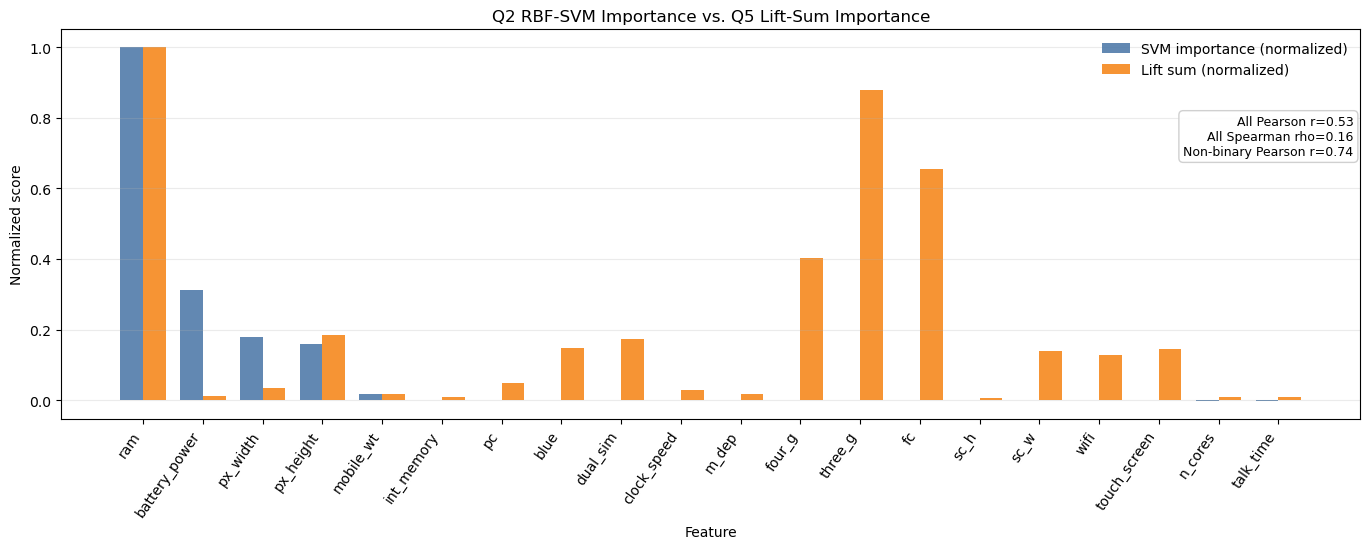

In [7]:
comparison = (
    pd.DataFrame({'feature': feature_names})
    .merge(svm_importance, on='feature')
    .merge(lift_df, on='feature')
)
comparison['svm_norm'] = comparison['svm_importance_mean'] / comparison['svm_importance_mean'].max()
comparison['lift_norm'] = comparison['lift_sum'] / comparison['lift_sum'].max()
comparison['is_binary'] = comparison['feature'].isin(['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi'])
comparison = comparison.sort_values('svm_importance_mean', ascending=False).reset_index(drop=True)
comparison.to_csv('results/q5_svm_lift_comparison.csv', index=False)

all_pearson = pearsonr(comparison['lift_sum'], comparison['svm_importance_mean'])
all_spearman = spearmanr(comparison['lift_sum'], comparison['svm_importance_mean'])
non_binary = ~comparison['is_binary']
nb_pearson = pearsonr(comparison.loc[non_binary, 'lift_sum'], comparison.loc[non_binary, 'svm_importance_mean'])
nb_spearman = spearmanr(comparison.loc[non_binary, 'lift_sum'], comparison.loc[non_binary, 'svm_importance_mean'])

similarity_metrics = pd.DataFrame([
    {'scope': 'all_features', 'n_features': len(comparison), 'pearson_r': all_pearson.statistic, 'pearson_p': all_pearson.pvalue, 'spearman_rho': all_spearman.statistic, 'spearman_p': all_spearman.pvalue},
    {'scope': 'non_binary_features', 'n_features': int(non_binary.sum()), 'pearson_r': nb_pearson.statistic, 'pearson_p': nb_pearson.pvalue, 'spearman_rho': nb_spearman.statistic, 'spearman_p': nb_spearman.pvalue},
])
similarity_metrics.to_csv('results/q5_similarity_metrics.csv', index=False)

print('Similarity metrics:')
print(similarity_metrics.to_string(index=False))

bar_df = comparison.sort_values('svm_importance_mean', ascending=False).reset_index(drop=True)
x = np.arange(len(bar_df))
width = 0.38

fig, ax = plt.subplots(figsize=(13.8, 5.6))
ax.bar(x - width / 2, bar_df['svm_norm'], width=width, color='#4c78a8', alpha=0.88, label='SVM importance (normalized)')
ax.bar(x + width / 2, bar_df['lift_norm'], width=width, color='#f58518', alpha=0.88, label='Lift sum (normalized)')

ax.set_xticks(x)
ax.set_xticklabels(bar_df['feature'], rotation=55, ha='right')
ax.set_ylabel('Normalized score')
ax.set_xlabel('Feature')
ax.set_title('Q2 RBF-SVM Importance vs. Q5 Lift-Sum Importance')
ax.grid(True, alpha=0.25, axis='y')
ax.legend(frameon=False, loc='upper right')
ax.text(
    0.995,
    0.78,
    f"All Pearson r={all_pearson.statistic:.2f}\nAll Spearman rho={all_spearman.statistic:.2f}\nNon-binary Pearson r={nb_pearson.statistic:.2f}",
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#cccccc', alpha=0.92),
)

plt.tight_layout()
plt.savefig('report/figures/q5_svm_lift_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Weighted PCA Analysis


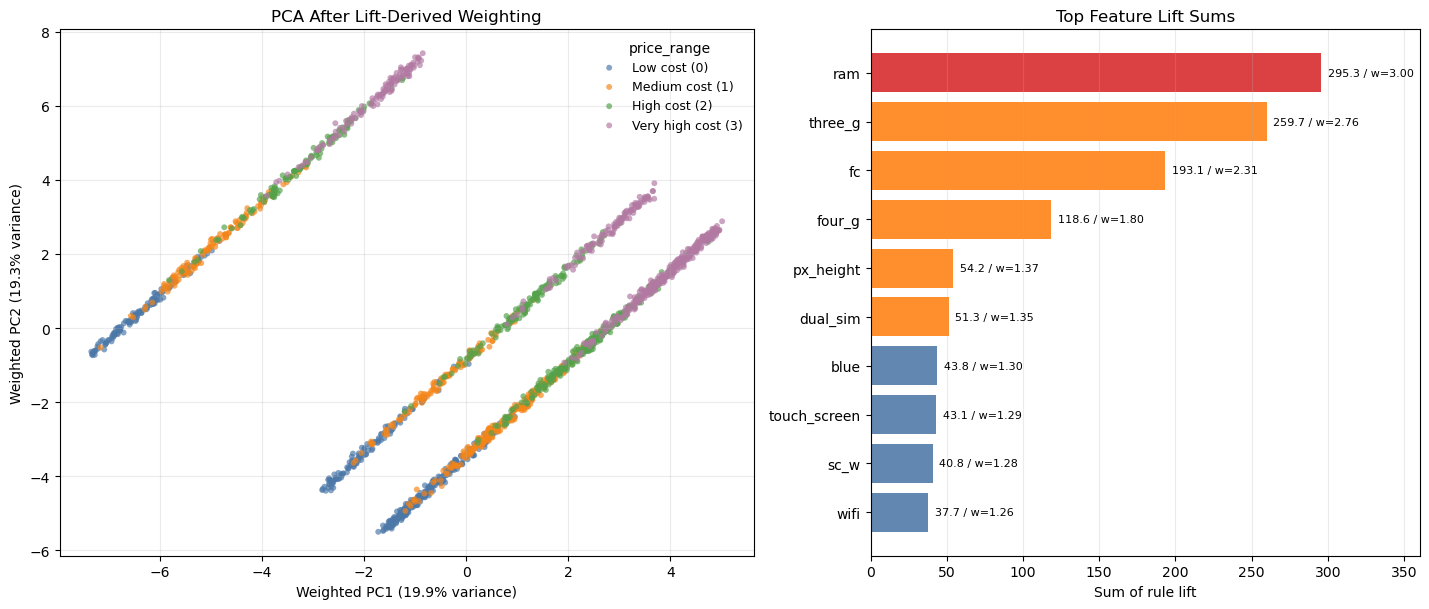

Weighted PCA explained variance: PC1=0.1988, PC2=0.1928, total=0.3916


In [8]:
X_weighted = X_scaled * weights[np.newaxis, :]

pca_weighted = PCA(n_components=2, random_state=42)
weighted_pca_coords = pca_weighted.fit_transform(X_weighted)
weighted_pca_var = pca_weighted.explained_variance_ratio_

colors_pca = ['#4c78a8', '#f58518', '#54a24b', '#b279a2']
fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.2), gridspec_kw={'width_ratios': [1.2, 0.95]})
ax_pca, ax_lift = axes

for cls, (label, color) in enumerate(zip(class_labels, colors_pca)):
    mask = y == cls
    ax_pca.scatter(
        weighted_pca_coords[mask, 0],
        weighted_pca_coords[mask, 1],
        s=18,
        alpha=0.68,
        color=color,
        label=label,
        edgecolors='none',
    )

ax_pca.set_xlabel(f'Weighted PC1 ({weighted_pca_var[0] * 100:.1f}% variance)')
ax_pca.set_ylabel(f'Weighted PC2 ({weighted_pca_var[1] * 100:.1f}% variance)')
ax_pca.set_title('PCA After Lift-Derived Weighting')
ax_pca.grid(True, alpha=0.25)
ax_pca.legend(title='price_range', frameon=False, loc='best', fontsize=9)

top_lift_n = 10
lift_order = np.argsort(lift_sum)[-top_lift_n:]
lift_names = [feature_names[i] for i in lift_order]
lift_values = lift_sum[lift_order]
lift_weights = weights[lift_order]
lift_colors = ['#d62728' if name == 'ram' else '#ff7f0e' if weight > 1.3 else '#4c78a8' for name, weight in zip(lift_names, lift_weights)]

bars = ax_lift.barh(lift_names, lift_values, color=lift_colors, alpha=0.88)
ax_lift.set_xlabel('Sum of rule lift')
ax_lift.set_title('Top Feature Lift Sums')
ax_lift.grid(True, alpha=0.25, axis='x')
for bar, value, weight in zip(bars, lift_values, lift_weights):
    ax_lift.text(
        value + max(lift_values) * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f} / w={weight:.2f}',
        va='center',
        fontsize=8,
    )
ax_lift.set_xlim(0, max(lift_values) * 1.22)

plt.tight_layout()
plt.savefig('report/figures/q5_lift_weighted_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Weighted PCA explained variance: PC1={weighted_pca_var[0]:.4f}, PC2={weighted_pca_var[1]:.4f}, total={weighted_pca_var[:2].sum():.4f}')


## Randomization Ablation


Ablation summary:
                          method  n_evaluations  ARI_mean  ARI_std  NMI_mean  accuracy_mean  f1_mean
   Baseline equal-weight K-Means              5  0.005838 0.000611  0.007806        0.29620 0.294082
   Correct lift-weighted K-Means              5  0.176932 0.000911  0.210937        0.44210 0.428476
Randomly reassigned lift weights            100  0.049718 0.096453  0.069595        0.31678 0.316056
Random permutation selected for confusion matrix: perm_id=17, mean ARI=0.0162


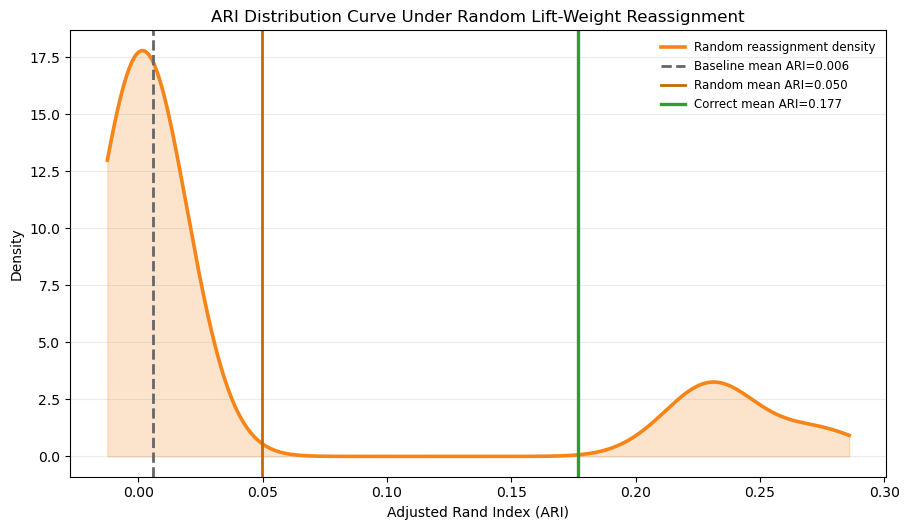

In [9]:
correct_results = run_kmeans_evaluation(X_weighted, 'Correct lift-weighted K-Means')

rng = np.random.default_rng(42)
random_rows = []
permuted_weights = {}

for perm_id in range(random_permutations):
    perm = rng.permutation(weights)
    permuted_weights[perm_id] = perm
    X_random_weighted = X_scaled * perm[np.newaxis, :]
    for seed in seeds:
        km = KMeans(n_clusters=4, random_state=seed, n_init=10)
        clusters = km.fit_predict(X_random_weighted)
        metrics = evaluate_clustering(y, clusters)
        metrics.pop('contingency')
        metrics.update({'seed': seed, 'perm_id': perm_id, 'method': 'Randomly reassigned lift weights'})
        random_rows.append(metrics)

random_results = pd.DataFrame(random_rows)
random_perm_summary = random_results.groupby('perm_id')['ARI'].mean().reset_index(name='mean_ARI')
random_mean_ari = random_results['ARI'].mean()
representative_perm_id = int(random_perm_summary.iloc[(random_perm_summary['mean_ARI'] - random_mean_ari).abs().argmin()]['perm_id'])
representative_random_weights = permuted_weights[representative_perm_id]

summary_rows = []
for method, data in [
    ('Baseline equal-weight K-Means', baseline_results),
    ('Correct lift-weighted K-Means', correct_results),
    ('Randomly reassigned lift weights', random_results),
]:
    summary_rows.append({
        'method': method,
        'n_evaluations': len(data),
        'ARI_mean': data['ARI'].mean(),
        'ARI_std': data['ARI'].std(ddof=1),
        'NMI_mean': data['NMI'].mean(),
        'accuracy_mean': data['accuracy'].mean(),
        'f1_mean': data['f1'].mean(),
    })

ablation_summary = pd.DataFrame(summary_rows)
all_ablation_results = pd.concat([
    baseline_results.assign(perm_id=np.nan),
    correct_results.assign(perm_id=np.nan),
    random_results,
], ignore_index=True)

ablation_summary.to_csv('results/q5_ablation_summary.csv', index=False)
all_ablation_results.to_csv('results/q5_random_ablation.csv', index=False)

print('Ablation summary:')
print(ablation_summary.to_string(index=False))
print(f'Random permutation selected for confusion matrix: perm_id={representative_perm_id}, mean ARI={random_perm_summary.loc[random_perm_summary.perm_id == representative_perm_id, "mean_ARI"].iloc[0]:.4f}')

from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9.2, 5.4))
random_ari = random_results['ARI'].to_numpy()
baseline_mean = baseline_results['ARI'].mean()
correct_mean = correct_results['ARI'].mean()
random_mean = random_ari.mean()

x_min = min(random_ari.min(), baseline_mean) - 0.012
x_max = max(random_ari.max(), correct_mean) + 0.012
x_grid = np.linspace(x_min, x_max, 600)
# A slightly narrow bandwidth keeps the multi-modal random distribution visible.
kde = gaussian_kde(random_ari, bw_method=0.18)
density = kde(x_grid)

ax.plot(x_grid, density, color='#f58518', linewidth=2.6, label='Random reassignment density')
ax.fill_between(x_grid, density, color='#f58518', alpha=0.22)
ax.axvline(baseline_mean, color='#666666', linestyle='--', linewidth=2.0, label=f'Baseline mean ARI={baseline_mean:.3f}')
ax.axvline(random_mean, color='#c46a00', linestyle='-', linewidth=2.0, label=f'Random mean ARI={random_mean:.3f}')
ax.axvline(correct_mean, color='#2ca02c', linestyle='-', linewidth=2.4, label=f'Correct mean ARI={correct_mean:.3f}')

ax.set_xlabel('Adjusted Rand Index (ARI)')
ax.set_ylabel('Density')
ax.set_title('ARI Distribution Curve Under Random Lift-Weight Reassignment')
ax.grid(True, alpha=0.25, axis='y')
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout()
plt.savefig('report/figures/q5_random_ablation_ari.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion/Contingency Matrix Comparison


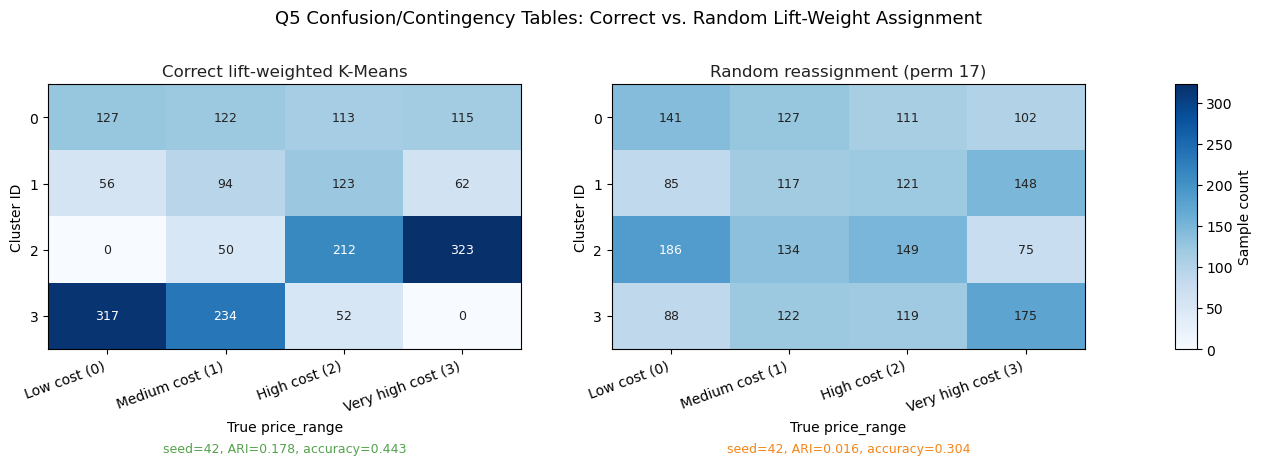

Correct lift-weighted metrics at representative seed:
{'accuracy': 0.4425, 'precision': 0.4252, 'recall': 0.4425, 'f1': 0.4286, 'ARI': 0.1778, 'NMI': 0.2116}
Representative random reassignment metrics at representative seed:
{'accuracy': 0.3045, 'precision': 0.3025, 'recall': 0.3045, 'f1': 0.3033, 'ARI': 0.0161, 'NMI': 0.019}


In [10]:
def clustering_contingency_for_plot(X_input, seed):
    km = KMeans(n_clusters=4, random_state=seed, n_init=10)
    clusters = km.fit_predict(X_input)
    metrics = evaluate_clustering(y, clusters)
    return clusters, metrics['contingency'], metrics

correct_clusters, correct_ct, correct_metrics = clustering_contingency_for_plot(X_weighted, representative_seed)
random_clusters, random_ct, random_metrics = clustering_contingency_for_plot(X_scaled * representative_random_weights[np.newaxis, :], representative_seed)

fig = plt.figure(figsize=(13.2, 5.0))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.045], wspace=0.28)
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
cax = fig.add_subplot(gs[0, 2])
plots = [
    ('Correct lift-weighted K-Means', correct_ct, correct_metrics, '#54a24b'),
    (f'Random reassignment (perm {representative_perm_id})', random_ct, random_metrics, '#f58518'),
]

vmax = max(correct_ct.values.max(), random_ct.values.max())
for ax, (title, ct, metrics, color) in zip(axes, plots):
    im = ax.imshow(ct.values, cmap='Blues', aspect='auto', vmin=0, vmax=vmax)
    ax.set_title(title, color='#222222')
    ax.set_xlabel('True price_range')
    ax.set_xticks(range(4))
    ax.set_xticklabels(class_labels, rotation=20, ha='right')
    ax.set_yticks(range(4))
    ax.set_yticklabels(range(4))
    ax.set_ylabel('Cluster ID')
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            value = ct.values[i, j]
            ax.text(j, i, str(value), ha='center', va='center', color='white' if value > vmax * 0.55 else '#222222', fontsize=9)
    ax.text(
        0.5,
        -0.35,
        f"seed={representative_seed}, ARI={metrics['ARI']:.3f}, accuracy={metrics['accuracy']:.3f}",
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=9,
        color=color,
    )

fig.colorbar(im, cax=cax, label='Sample count')
fig.suptitle('Q5 Confusion/Contingency Tables: Correct vs. Random Lift-Weight Assignment', fontsize=13)
fig.subplots_adjust(bottom=0.30, top=0.83, left=0.06, right=0.93)
plt.savefig('report/figures/q5_random_ablation_confusion.png', dpi=150, bbox_inches='tight')
plt.savefig('report/figures/q5_contingency.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correct lift-weighted metrics at representative seed:')
print({k: round(v, 4) for k, v in correct_metrics.items() if k != 'contingency'})
print('Representative random reassignment metrics at representative seed:')
print({k: round(v, 4) for k, v in random_metrics.items() if k != 'contingency'})

## Final Numbers For Report


In [11]:
print('Report-ready values')
print('All-feature Pearson r:', round(all_pearson.statistic, 3), 'p:', round(all_pearson.pvalue, 4))
print('All-feature Spearman rho:', round(all_spearman.statistic, 3), 'p:', round(all_spearman.pvalue, 4))
print('Non-binary Pearson r:', round(nb_pearson.statistic, 3), 'p:', round(nb_pearson.pvalue, 4))
print('Weighted PCA total first two PCs:', round(weighted_pca_var[:2].sum(), 4))
print('\nAblation summary:')
print(ablation_summary.to_string(index=False))


Report-ready values
All-feature Pearson r: 0.535 p: 0.0151
All-feature Spearman rho: 0.156 p: 0.5103
Non-binary Pearson r: 0.744 p: 0.0023
Weighted PCA total first two PCs: 0.3916

Ablation summary:
                          method  n_evaluations  ARI_mean  ARI_std  NMI_mean  accuracy_mean  f1_mean
   Baseline equal-weight K-Means              5  0.005838 0.000611  0.007806        0.29620 0.294082
   Correct lift-weighted K-Means              5  0.176932 0.000911  0.210937        0.44210 0.428476
Randomly reassigned lift weights            100  0.049718 0.096453  0.069595        0.31678 0.316056
